### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


# Atif's assignment starts here

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt

### Observing the data

Below, we will load the `.csv` file and create a data frame. We will look at the shape, columns, and descriptive statistics.

In [28]:
df_grades = pd.read_csv("grades_crpt.csv")
display(df_grades)
display (f"The shape of the dataframe is: {df_grades.shape}")
columns = [*df_grades.columns]
print(f"Columns are: {columns}")
print("\nGiven below are descriptive stats on the numerical columns\n")
df_grades.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


'The shape of the dataframe is: (86, 9)'

Columns are: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam', 'user_id']

Given below are descriptive stats on the numerical columns



,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


Observing the dataframe, this is what we know:

- There are 86 rows (85 entries because the first row is column header)
- There are 9 columns. 7 assignments + final exam + user id
- There are a few missing values in the assignment columns. I will show the exact number below using python code.
- Using the descriptive stats table, I can see negative values for A1, A2, A3, A4, and A6.
- A2 max should be 100 + 15 = 115, but we see a max of 148.9. This is unusual.
- A4 max should be 100 + 5 = 105, but we see a max of 188.2. This is unusual.
- A6 max should be 100 + 10 = 110, but we see 183.6. This is unusual.

Below, let us count the number of missing values.

In [29]:
a1_missing = df_grades["A1"].isnull().sum()
a2_missing = df_grades["A2"].isnull().sum()
a3_missing = df_grades["A3"].isnull().sum()
a4_missing = df_grades["A4"].isnull().sum()
a5_missing = df_grades["A5"].isnull().sum()
a6_missing = df_grades["A6"].isnull().sum()
a7_missing = df_grades["A7"].isnull().sum()
final_missing = df_grades["Final_Exam"].isnull().sum()
id_missing = df_grades["user_id"].isnull().sum()

print(f"There are {a1_missing} missing values in A1 column")
print(f"There are {a2_missing} missing values in A2 column")
print(f"There are {a3_missing} missing values in A3 column")
print(f"There are {a4_missing} missing values in A4 column")
print(f"There are {a5_missing} missing values in A5 column")
print(f"There are {a6_missing} missing values in A6 column")
print(f"There are {a7_missing} missing values in A7 column")
print(f"There are {final_missing} missing values in final column")
print(f"There are {id_missing} missing values in user id column")



There are 29 missing values in A1 column
There are 25 missing values in A2 column
There are 24 missing values in A3 column
There are 9 missing values in A4 column
There are 25 missing values in A5 column
There are 19 missing values in A6 column
There are 10 missing values in A7 column
There are 0 missing values in final column
There are 0 missing values in user id column


### Missing values

- There are 29 missing values in the `A1` column
- There are 25 missing values in the `A2` column
- There are 24 missing values in the `A3` column
- There are 9 missing values in the `A4` column
- There are 25 missing values in the `A5` column
- There are 19 missing values in the `A6` column
- There are 10 missing values in the `A7` column
- There are no missing values in the `Final_Exam` and `user_id` columns


### Observing the outliers

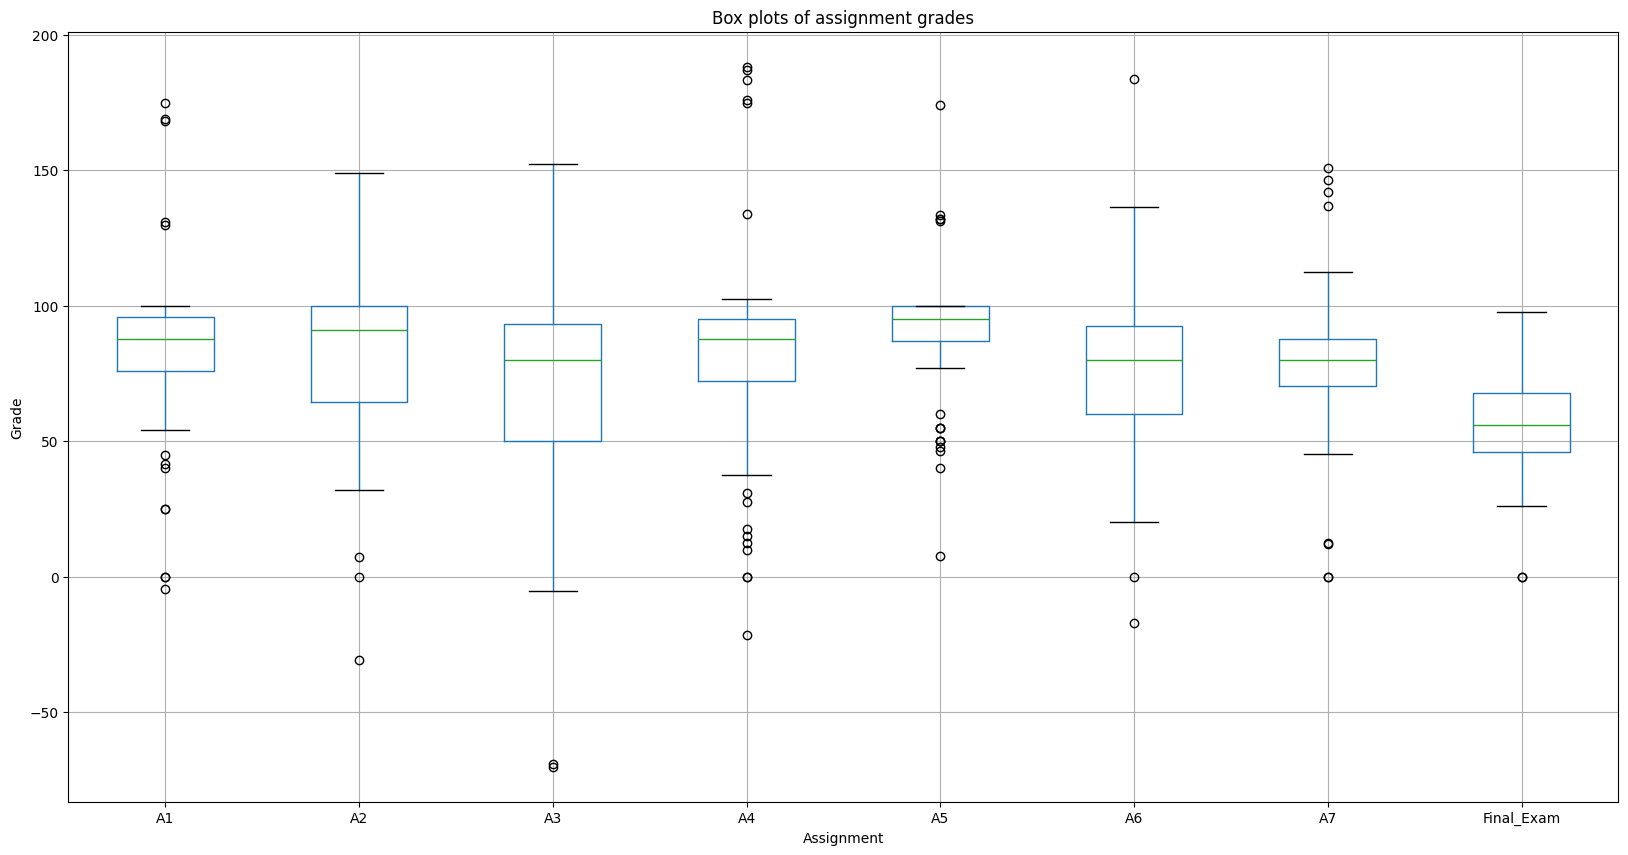

In [30]:
plt.figure(figsize=(20,10))
df_grades.boxplot(column=["A1", "A2", "A3", "A4", "A5", "A6", "A7", "Final_Exam"])
plt.title("Box plots of assignment grades")
plt.xlabel("Assignment")
plt.ylabel("Grade")
plt.show()

The outliers can be shown above which are above or below the whiskers. The outliers, or unusual grades, which are above the theoretical maximum grade, and the ones that are below zero need to be removed because they theoretically cannot exist.. Below, I will list all such unusual grades.

I will replace the outliers with imputation. Removing them will cause us to lose data on the other assignments. However, we must consider that this might result in the student having a better or worse grade than they deserve. The strategy I am using here, is that for any assignment that has an unusual/strange value, I will replace it with the average of all other assingments of students that have not-unusual values, celing to a 100.

In [31]:
# Assignment 1 strange values
unusual_assignment1 = df_grades.loc[(df_grades["A1"] < 0) | (df_grades["A1"] > 100)]
print("Given below are strange values for Assignment 1")
display(unusual_assignment1[["A1", "user_id"]])

# Assignment 1 missing values
missing_assignment1 = df_grades.loc[(df_grades["A1"].isnull())]
print("Given below are missing values for Assignment 1")
display(missing_assignment1[["A1", "user_id"]])


# Assignment 2 strange values
unusual_assignment2 = df_grades.loc[(df_grades["A2"] < 0) | (df_grades["A2"] > 115)]
print("Given below are strange values for Assignment 2")
display(unusual_assignment2[["A2", "user_id"]])

# Assignment 2 missing values
missing_assignment2 = df_grades.loc[(df_grades["A2"].isnull())]
print("Given below are missing values for Assignment 2")
display(missing_assignment2[["A2", "user_id"]])

# Assignment 3 strange values
unusual_assignment3 = df_grades.loc[(df_grades["A3"] < 0) | (df_grades["A3"] > 100)]
print("Given below are strange values for Assignment 3")
display(unusual_assignment3[["A3", "user_id"]])

# Assignment 3 missing values
missing_assignment3 = df_grades.loc[(df_grades["A3"].isnull())]
print("Given below are missing values for Assignment 3")
display(missing_assignment3[["A3", "user_id"]])

# Assignment 4 strange values
unusual_assignment4 = df_grades.loc[(df_grades["A4"] < 0) | (df_grades["A4"] > 105)]
print("Given below are strange values for Assignment 4")
display(unusual_assignment4[["A4", "user_id"]])

# Assignment 4 missing values
missing_assignment4 = df_grades.loc[(df_grades["A4"].isnull())]
print("Given below are missing values for Assignment 4")
display(missing_assignment1[["A4", "user_id"]])

# Assignment 5 strange values
unusual_assignment5 = df_grades.loc[(df_grades["A5"] < 0) | (df_grades["A5"] > 100)]
print("Given below are strange values for Assignment 5")
display(unusual_assignment5[["A5", "user_id"]])

# Assignment 5 missing values
missing_assignment5 = df_grades.loc[(df_grades["A5"].isnull())]
print("Given below are missing values for Assignment 5")
display(missing_assignment5[["A5", "user_id"]])

# Assignment 6 strange values
unusual_assignment6 = df_grades.loc[(df_grades["A6"] < 0) | (df_grades["A6"] > 110)]
print("Given below are strange values for Assignment 6")
display(unusual_assignment6[["A6", "user_id"]])

# Assignment 6 missing values
missing_assignment6 = df_grades.loc[(df_grades["A6"].isnull())]
print("Given below are missing values for Assignment 6")
display(missing_assignment1[["A6", "user_id"]])

# Assignment 7 strange values
unusual_assignment7 = df_grades.loc[(df_grades["A7"] < 0) | (df_grades["A7"] > 100)]
print("Given below are strange values for Assignment 7")
display(unusual_assignment7[["A7", "user_id"]])

# Assignment 7 missing values
missing_assignment7 = df_grades.loc[(df_grades["A7"].isnull())]
print("Given below are missing values for Assignment 7")
display(missing_assignment7[["A7", "user_id"]])

# Final exam strange values
unusual_final = df_grades.loc[(df_grades["Final_Exam"] < 0) | (df_grades["Final_Exam"] > 100)]
print("Given below are strange values for Final Exam")
display(unusual_final[["Final_Exam", "user_id"]])

# Final exam missing values
missing_final = df_grades.loc[(df_grades["Final_Exam"].isnull())]
print("Given below are missing values for Assignment 7")
display(missing_final[["Final_Exam", "user_id"]])
        

Given below are strange values for Assignment 1


,A1,user_id
7,168.9,U008
9,129.9,U010
15,168.1,U016
16,174.6,U017
24,130.7,U025
44,-4.5,U045


Given below are missing values for Assignment 1


,A1,user_id
0,NaN,U001
13,NaN,U014
17,NaN,U018
19,NaN,U020
22,NaN,U023
26,NaN,U027
28,NaN,U029
33,NaN,U034
35,NaN,U036
37,NaN,U038


Given below are strange values for Assignment 2


...

,A7,user_id
2,NaN,U003
4,NaN,U005
7,NaN,U008
27,NaN,U028
36,NaN,U037
40,NaN,U041
47,NaN,U048
51,NaN,U052
56,NaN,U057
65,NaN,U066


Given below are strange values for Final Exam


,Final_Exam,user_id


Given below are missing values for Assignment 7


,Final_Exam,user_id


### Unusual values

#### Assignment 1

In A1, there 6 entries with unusual values. They are given here

| `user_id` | A1 grade |
------------|----------|
| U008        |    168.9 |
| U010        |    129.9 |
| U016        |    168.1 |
| U017        |    174.6 |
| U025        |    130.7 |
| U045        |     -4.5 |


#### Assignment 2

In A2, there 2 entries with unusual values. They are given here

| `user_id` | A2 grade |
------------|----------|
| U045      |    148.9 |
| U083      |    -30.6 |

#### Assignment 3

In A3, there 7 entries with unusual values. They are given here

| `user_id` | A3 grade |
------------|----------|
| U010        |    -5.3  |
| U013        |    -69.3 |
| U017        |    149.2 |
| U027        |    -1.7  |
| U053        |    -70.1 |
| U055        |    152.2 |
| U067        |    150.8 |

#### Assignment 4

In A4, there 7 entries with unusual values. They are given here

| `user_id` | A4 grade |
------------|----------|
| U007        | 175.8  |
| U025        | 188.2  | 
| U029        | 133.8  |
| U031        | 183.1  |
| U037        | 187.1  |
| U068        |  -21.6 |
| U083        | 174.8  |

#### Assignment 5

In A5, there 5 entries with unusual values. They are given here

| `user_id` | A5 grade |
------------|----------|
| U057        | 132.0  |
| U061        | 131.8  | 
| U062        | 173.9  |
| U063        | 131.4  |
| U074        | 133.4  |


#### Assignment 6

In A6, there 3 entries with unusual values. They are given here

| `user_id` | A6 grade |
------------|----------|
| U013        | 183.6  |
| U046        | 136.4  | 
| U077        | -17.0  |

#### Assignment 7

In A7, there 7 entries with unusual values. They are given here

| `user_id` | A7 grade |
------------|----------|
| U006      |   110.5  |
| U015      |  142.1   |
| U051      |    136.9 |
| U059      |    110.3 |
| U069      |    150.6 |
| U073      |    112.3 |
| U083      |    146.4 |

#### Final Exam

There are no issues in final exam grades.

#### Replacing missing and unusual values

I can create a modular function that can handle a lot of the tables, but now I will deal with each of the rows individually, as shown in lab. I can find the rows that have missing and unusual values by joining the tables.



In [32]:
## Assignment 1: missing and unusual values
omit_assignment_1 = pd.concat([unusual_assignment1["user_id"], missing_assignment1["user_id"]], ignore_index=True)
print("Given below are the users with missing or strange values in Assignment 1")
display(omit_assignment_1)

## Assignment 2: missing and unusual values
omit_assignment_2 = pd.concat([unusual_assignment2["user_id"], missing_assignment2["user_id"]], ignore_index=True)
print("Given below are the users with missing or strange values in Assignment 2")
display(omit_assignment_2)

## Assignment 3: missing and unusual values
omit_assignment_3 = pd.concat([unusual_assignment3["user_id"], missing_assignment3["user_id"]], ignore_index=True)
print("Given below are the users with missing or strange values in Assignment 3")
display(omit_assignment_3)

## Assignment 4: missing and unusual values
omit_assignment_4 = pd.concat([unusual_assignment4["user_id"], missing_assignment4["user_id"]], ignore_index=True)
print("Given below are the users with missing or strange values in Assignment 4")
display(omit_assignment_4)

## Assignment 5: missing and unusual values
omit_assignment_5 = pd.concat([unusual_assignment5["user_id"], missing_assignment5["user_id"]], ignore_index=True)
print("Given below are the users with missing or strange values in Assignment 5")
display(omit_assignment_5)

## Assignment 6: missing and unusual values
omit_assignment_6 = pd.concat([unusual_assignment6["user_id"], missing_assignment6["user_id"]], ignore_index=True)
print("Given below are the users with missing or strange values in Assignment 6")
display(omit_assignment_6)

## Assignment 7: missing and unusual values
omit_assignment_7 = pd.concat([unusual_assignment7["user_id"], missing_assignment7["user_id"]], ignore_index=True)
print("Given below are the users with missing or strange values in Assignment 7")
display(omit_assignment_7)

## Final exam: missing and unusual values
omit_final = pd.concat([unusual_final["user_id"], missing_final["user_id"]], ignore_index=True)
print("Given below are the users with missing or strange values in Final Exam")
display(omit_final)

Given below are the users with missing or strange values in Assignment 1


0     U008
1     U010
2     U016
3     U017
4     U025
5     U045
6     U001
7     U014
8     U018
9     U020
10    U023
11    U027
12    U029
13    U034
14    U036
15    U038
16    U040
17    U042
18    U046
19    U047
20    U049
21    U051
22    U056
23    U058
24    U061
25    U062
26    U063
27    U064
28    U067
29    U069
30    U071
31    U076
32    U079
33    U082
34    U085
Name: user_id, dtype: str

Given below are the users with missing or strange values in Assignment 2


0     U045
1     U083
2     U001
3     U002
4     U005
5     U014
6     U025
7     U026
8     U027
9     U032
10    U036
11    U037
12    U038
13    U039
14    U040
15    U044
16    U056
17    U058
18    U059
19    U061
20    U065
21    U067
22    U069
23    U071
24    U082
25    U084
26    U086
Name: user_id, dtype: str

Given below are the users with missing or strange values in Assignment 3


...

0     U013
1     U046
2     U077
3     U003
4     U005
5     U011
6     U020
7     U022
8     U024
9     U030
10    U037
11    U039
12    U045
13    U049
14    U050
15    U051
16    U057
17    U067
18    U069
19    U071
20    U081
21    U083
Name: user_id, dtype: str

Given below are the users with missing or strange values in Assignment 7


0     U006
1     U015
2     U051
3     U059
4     U069
5     U073
6     U083
7     U003
8     U005
9     U008
10    U028
11    U037
12    U041
13    U048
14    U052
15    U057
16    U066
Name: user_id, dtype: str

Given below are the users with missing or strange values in Final Exam


Series([], Name: user_id, dtype: str)

Now that we know what the values we need omit are, we can go ahead with calculating the means.

#### Trying imputation with mean

In [33]:
# Make a copy just to be safe
df_grades_copy = df_grades.copy()

# Replacing values assignment 1
non_outlier_a1 = df_grades_copy[~df_grades_copy['user_id'].isin(omit_assignment_1)]['A1']
mean_a1 = non_outlier_a1.mean()
print(f"The mean for assignment 1 without outliers is {mean_a1}")
df_grades_copy.loc[df_grades_copy['user_id'].isin(omit_assignment_1), 'A1'] = round(mean_a1, 1)

# Replacing values assignment 2
non_outlier_a2 = df_grades_copy[~df_grades_copy['user_id'].isin(omit_assignment_2)]['A2']
mean_a2 = non_outlier_a2.mean()
print(f"The mean for assignment 2 without outliers is {mean_a2}")
df_grades_copy.loc[df_grades_copy['user_id'].isin(omit_assignment_2), 'A2'] = round(mean_a2, 1)

# Replacing values assignment 3
non_outlier_a3 = df_grades_copy[~df_grades_copy['user_id'].isin(omit_assignment_3)]['A3']
mean_a3 = non_outlier_a3.mean()
print(f"The mean for assignment 3 without outliers is {mean_a3}")
df_grades_copy.loc[df_grades_copy['user_id'].isin(omit_assignment_3), 'A3'] = round(mean_a3, 1)

# Replacing values assignment 4
non_outlier_a4 = df_grades_copy[~df_grades_copy['user_id'].isin(omit_assignment_4)]['A4']
mean_a4 = non_outlier_a4.mean()
print(f"The mean for assignment 4 without outliers is {mean_a4}")
df_grades_copy.loc[df_grades_copy['user_id'].isin(omit_assignment_4), 'A4'] = round(mean_a4, 2)

# Replacing values assignment 5
non_outlier_a5 = df_grades_copy[~df_grades_copy['user_id'].isin(omit_assignment_5)]['A5']
mean_a5 = non_outlier_a5.mean()
print(f"The mean for assignment 5 without outliers is {mean_a5}")
df_grades_copy.loc[df_grades_copy['user_id'].isin(omit_assignment_5), 'A5'] = round(mean_a5, 2)

# Replacing values assignment 6
non_outlier_a6 = df_grades_copy[~df_grades_copy['user_id'].isin(omit_assignment_6)]['A6']
mean_a6 = non_outlier_a6.mean()
print(f"The mean for assignment 6 without outliers is {mean_a6}")
df_grades_copy.loc[df_grades_copy['user_id'].isin(omit_assignment_6), 'A6'] = round(mean_a6, 2)

# Replacing values assignment 7
non_outlier_a7 = df_grades_copy[~df_grades_copy['user_id'].isin(omit_assignment_7)]['A7']
mean_a7 = non_outlier_a7.mean()
print(f"The mean for assignment 7 without outliers is {mean_a7}")
df_grades_copy.loc[df_grades_copy['user_id'].isin(omit_assignment_7), 'A7'] = round(mean_a7, 2)

# Display the final table
display(df_grades_copy)

The mean for assignment 1 without outliers is 78.4627450980392
The mean for assignment 2 without outliers is 81.84067796610168
The mean for assignment 3 without outliers is 71.2909090909091
The mean for assignment 4 without outliers is 75.97714285714284
The mean for assignment 5 without outliers is 85.10535714285713
The mean for assignment 6 without outliers is 73.1921875
The mean for assignment 7 without outliers is 72.88115942028986


,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,78.5,81.8,30.0,75.00,90.00,65.00,50.60,68.8,U001
1,100.0,81.8,71.3,92.50,100.00,100.00,84.40,50.3,U002
2,75.0,69.6,71.3,86.20,100.00,73.19,72.88,67.8,U003
3,25.0,78.6,40.0,0.00,50.00,30.70,0.00,0.0,U004
4,0.0,81.8,0.0,0.00,85.11,73.19,72.88,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,78.5,81.8,71.3,56.20,85.11,29.20,60.00,57.5,U082
82,87.5,81.8,70.0,75.98,91.00,73.19,72.88,64.1,U083
83,79.2,81.8,60.0,27.50,50.00,60.00,75.00,45.6,U084
84,78.5,0.0,85.0,100.00,55.00,0.00,0.00,30.6,U085


#### Trying imputation with median

In [34]:
# Make a copy just to be safe
df_grades_copy_median = df_grades.copy()

# Replacing values assignment 1
non_outlier_a1 = df_grades_copy_median[~df_grades_copy_median['user_id'].isin(omit_assignment_1)]['A1']
median_a1 = non_outlier_a1.median()
print(f"The median for assignment 1 without outliers is {median_a1}")
df_grades_copy_median.loc[df_grades_copy_median['user_id'].isin(omit_assignment_1), 'A1'] = round(median_a1, 1)

# Replacing values assignment 2
non_outlier_a2 = df_grades_copy_median[~df_grades_copy_median['user_id'].isin(omit_assignment_2)]['A2']
median_a2 = non_outlier_a2.median()
print(f"The median for assignment 2 without outliers is {median_a2}")
df_grades_copy_median.loc[df_grades_copy_median['user_id'].isin(omit_assignment_2), 'A2'] = round(median_a2, 1)

# Replacing values assignment 3
non_outlier_a3 = df_grades_copy_median[~df_grades_copy_median['user_id'].isin(omit_assignment_3)]['A3']
median_a3 = non_outlier_a3.median()
print(f"The median for assignment 3 without outliers is {median_a3}")
df_grades_copy_median.loc[df_grades_copy_median['user_id'].isin(omit_assignment_3), 'A3'] = round(median_a3, 1)

# Replacing values assignment 4
non_outlier_a4 = df_grades_copy_median[~df_grades_copy_median['user_id'].isin(omit_assignment_4)]['A4']
median_a4 = non_outlier_a4.median()
print(f"The median for assignment 4 without outliers is {median_a4}")
df_grades_copy_median.loc[df_grades_copy_median['user_id'].isin(omit_assignment_4), 'A4'] = round(median_a4, 2)

# Replacing values assignment 5
non_outlier_a5_median = df_grades_copy_median[~df_grades_copy_median['user_id'].isin(omit_assignment_5)]['A5']
median_a5 = non_outlier_a5.median()
print(f"The median for assignment 5 without outliers is {median_a5}")
df_grades_copy_median.loc[df_grades_copy_median['user_id'].isin(omit_assignment_5), 'A5'] = round(median_a5, 2)

# Replacing values assignment 6
non_outlier_a6 = df_grades_copy_median[~df_grades_copy_median['user_id'].isin(omit_assignment_6)]['A6']
median_a6 = non_outlier_a6.median()
print(f"The median for assignment 6 without outliers is {median_a6}")
df_grades_copy_median.loc[df_grades_copy_median['user_id'].isin(omit_assignment_6), 'A6'] = round(median_a6, 2)

# Replacing values assignment 7
non_outlier_a7 = df_grades_copy_median[~df_grades_copy_median['user_id'].isin(omit_assignment_7)]['A7']
median_a7 = non_outlier_a7.median()
print(f"The median for assignment 7 without outliers is {median_a7}")
df_grades_copy_median.loc[df_grades_copy_median['user_id'].isin(omit_assignment_7), 'A7'] = round(median_a7, 2)

# Display the final table
display(df_grades_copy_median)

The median for assignment 1 without outliers is 83.3
The median for assignment 2 without outliers is 91.1
The median for assignment 3 without outliers is 80.0
The median for assignment 4 without outliers is 86.85
The median for assignment 5 without outliers is 91.0
The median for assignment 6 without outliers is 80.0
The median for assignment 7 without outliers is 78.8


,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,83.3,91.1,30.0,75.00,90.0,65.0,50.6,68.8,U001
1,100.0,91.1,80.0,92.50,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,80.0,86.20,100.0,80.0,78.8,67.8,U003
3,25.0,78.6,40.0,0.00,50.0,30.7,0.0,0.0,U004
4,0.0,91.1,0.0,0.00,91.0,80.0,78.8,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,83.3,91.1,80.0,56.20,91.0,29.2,60.0,57.5,U082
82,87.5,91.1,70.0,86.85,91.0,80.0,78.8,64.1,U083
83,79.2,91.1,60.0,27.50,50.0,60.0,75.0,45.6,U084
84,83.3,0.0,85.0,100.00,55.0,0.0,0.0,30.6,U085


### Comparing mean and median imputation
Generally median is more robust against outliers, and in cases where there are a high spread of values, like grades, median is a better choice over mean. Howeer, here, medians are higher than mean, so depending on if the professor is generous, either could be a good choice. I will select median. For comparison, I will also try with mean.

### Observing correlations below, using median imputation

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
A1,1.000000,0.069931,0.329696,0.395422,0.164789,0.302787,0.106811,0.350441
A2,0.069931,1.000000,0.199918,0.258637,0.040734,0.313262,0.161711,0.256887
A3,0.329696,0.199918,1.000000,0.413843,0.137151,0.198213,0.160838,0.295048
A4,0.395422,0.258637,0.413843,1.000000,0.164797,0.246219,0.172491,0.528597
A5,0.164789,0.040734,0.137151,0.164797,1.000000,0.387887,0.203401,0.103726
A6,0.302787,0.313262,0.198213,0.246219,0.387887,1.000000,0.279874,0.264425
A7,0.106811,0.161711,0.160838,0.172491,0.203401,0.279874,1.000000,0.259405
Final_Exam,0.350441,0.256887,0.295048,0.528597,0.103726,0.264425,0.259405,1.000000


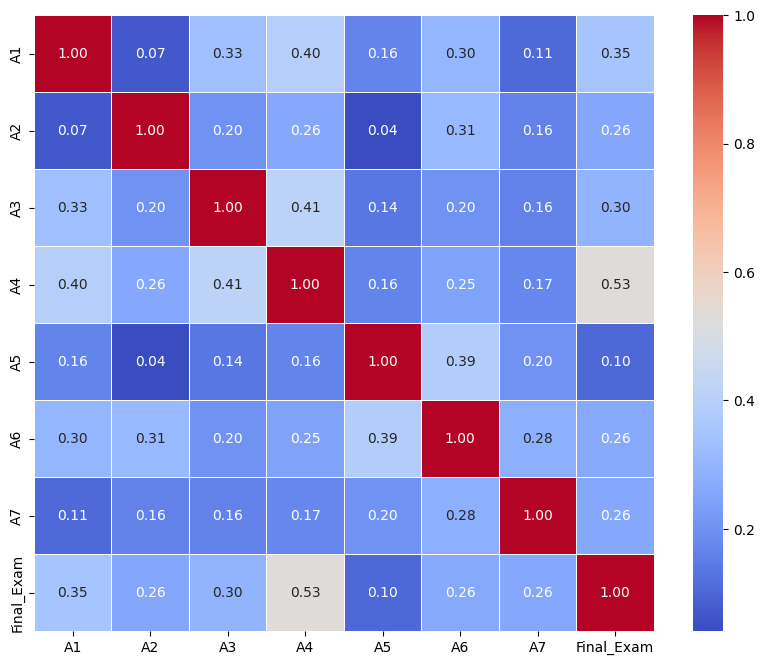

In [35]:
assignment_columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
correlation_matrix_median = df_grades_copy_median[assignment_columns].corr()
display (correlation_matrix_median)
plt.figure(figsize=(10,8 ))
sns.heatmap(correlation_matrix_median, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

Using median, the assignments that correlate the strongest with final exam performance are A1 and A4. These will be the two assingments I will chose to predict final exam performance.

### Observing correlations below, using mean imputation.

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
A1,1.000000,0.074656,0.366285,0.358640,0.156093,0.313408,0.134761,0.352337
A2,0.074656,1.000000,0.245267,0.253022,0.059611,0.305823,0.126421,0.264728
A3,0.366285,0.245267,1.000000,0.420972,0.125562,0.179821,0.164908,0.284686
A4,0.358640,0.253022,0.420972,1.000000,0.208134,0.226517,0.152154,0.494472
A5,0.156093,0.059611,0.125562,0.208134,1.000000,0.388783,0.191530,0.109692
A6,0.313408,0.305823,0.179821,0.226517,0.388783,1.000000,0.275081,0.261700
A7,0.134761,0.126421,0.164908,0.152154,0.191530,0.275081,1.000000,0.246451
Final_Exam,0.352337,0.264728,0.284686,0.494472,0.109692,0.261700,0.246451,1.000000


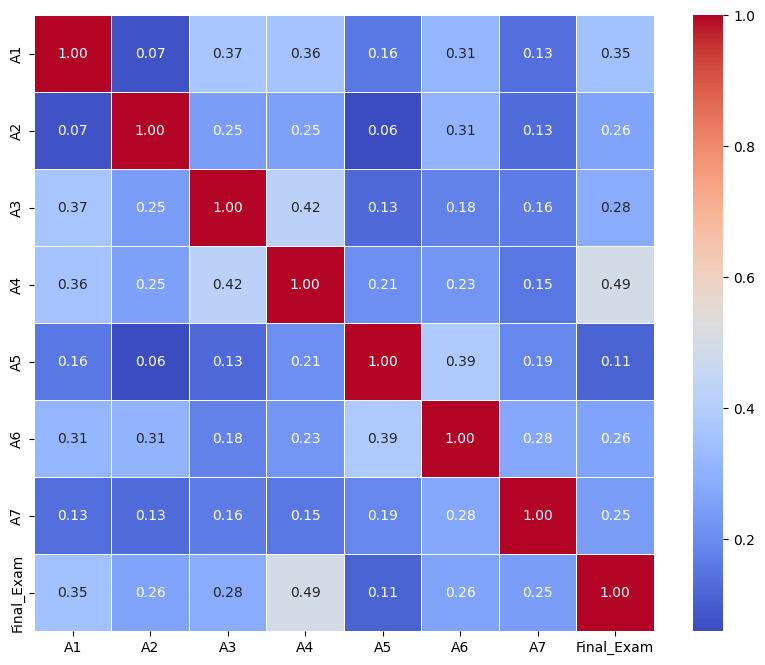

In [36]:
assignment_columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
correlation_matrix = df_grades_copy[assignment_columns].corr()
display (correlation_matrix)
plt.figure(figsize=(10,8 ))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

Using mean, the assignments that correlate the strongest with final exam performance are A1 and A4. These will be the two assingments I will chose to predict final exam performance. These assignments are same as in case of median, just the correlation value is different.